# Training a Model to Understand Audio-Reactive Spirographs
---

## Setup: Uploading Dataset Files


In [ ]:
from google.colab import files
import zipfile
import os

#upload dataset2.zip:
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

#unzip it:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data") #extract it

print(os.listdir("/content/data/dataset2")) #should show train and test
print("Classes:", os.listdir("/content/data/dataset2/train")) #shows all classes in train


Saving dataset2 3.zip to dataset2 3.zip
['test2', 'testsounds2', 'sounds2', 'train', '.DS_Store']
Classes: ['high_loud', 'low_loud', 'low_quiet', 'high_quiet', '.DS_Store']


In [ ]:
# Import required libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
import numpy as np
import matplotlib.pyplot as plt
import random

In [ ]:
# Check if GPU is available (copied from week 8, assignment 3)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if device.type != 'cuda':
    print("GPU not detected. Go to Runtime > Change runtime type > GPU if you want to use GPU for this session.")
    print("ps. This lab will be slow without GPU")

Using device: cuda


In [ ]:
# Set random seeds for reproducibility (also from week8)
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Part 1: Uploading my Dataset and Adding Transforms and Augmentation

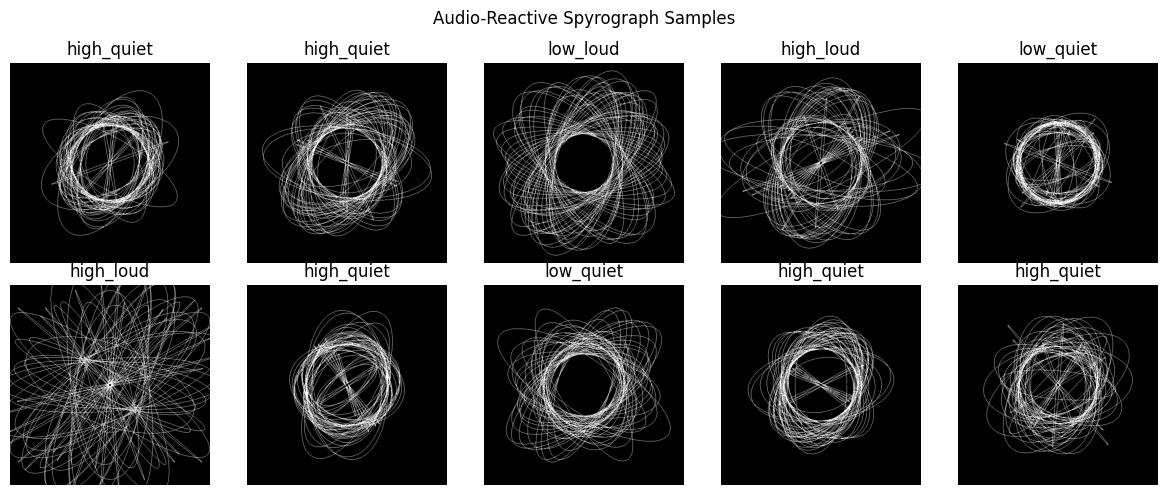

In [ ]:
#load MY dataset.. (modified from data augmentation visualisation in class)
basic_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), #needs to be 1 channel = greyscale - can i show them not in greyscale?
    transforms.ToTensor() #converts to tensors for model
])

viz_dataset = torchvision.datasets.ImageFolder(
    root='/content/data/dataset2/train', #uploading my dataset
    transform=basic_transform
)

classes = viz_dataset.classes #auto reads folder names as class labels


num_samples = 10 #adding 10 random indices so it shows me 10 random samples from all classes
random_indices = random.sample(range(len(viz_dataset)), num_samples)
#otherwise loops through first 10 which are first 10 of 'angry' since alphabetical

# Show original images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i, rnd_index in enumerate(random_indices): #for random indices
    img, label = viz_dataset[rnd_index] #changed i to random index
    img = img.squeeze(0) #removes channel dimension - 1, h, w to h, w (needs 2D arrays for greyscale) - just for plotting not training
    axes[i].imshow(img, cmap = 'gray') #added cmap so correctly displays greyscale as imshow usually RGB
    axes[i].set_title(f'{classes[label]}')
    axes[i].axis('off')
plt.suptitle('Audio-Reactive Spyrograph Samples')
plt.tight_layout()
plt.show()

# Define simple augmentations for training
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), #transforms applied per dataset instatiation
    transforms.Resize((256,256), interpolation=InterpolationMode.BICUBIC), #resize from 600x600 to 256x256 for less heavy
    #default resizing is bilinear SO changing interpolation mode to BICUBIC to keep curves, less blurry
    transforms.RandomHorizontalFlip(p=0.5), #so it doesn't have dataset biases like tilting heads
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) #normalise pixel values - more stable training
])

# Validation transform (no augmentation)
#no augmentation like flips etc. in validation set as need to see performance on 'real' data
#whereas training data needs some augmentation to improve generalisation
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


## Visualisation of Augmentation of data:

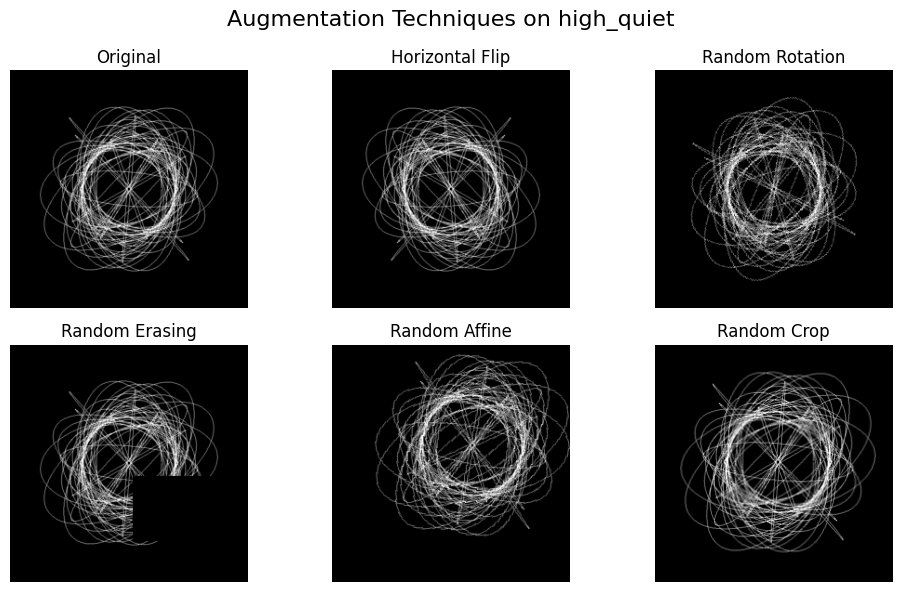

In [ ]:
# Define different augmentation techniques
augmentation_techniques = {
    "Original": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        #adding greyscale and resize for each augmentation for visualisation.
        transforms.Resize((256,256)),
        transforms.ToTensor(),
    ]),
    "Horizontal Flip": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256,256)),
        transforms.RandomHorizontalFlip(p=1),  # Always flip for demo
        transforms.ToTensor(),
    ]),
    "Random Rotation": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256,256)),
        transforms.RandomRotation(degrees=25),
        transforms.ToTensor(),
    ]),
    "Random Erasing": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=1, scale=(0.01, 0.1)),
    ]),
    "Random Affine": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256,256)),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
    ]),
    "Random Crop": transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((256,256)),
        transforms.RandomCrop(234, padding=4),  # Pad then crop
        transforms.ToTensor(),
    ]),
}

# Visualize augmentations on a single image
fig, axes = plt.subplots(2, 3, figsize=(10, 6)) #changed as i have less pictures so 1x4 and 12x4 to fit better
axes = axes.ravel()

for idx, (name, transform) in enumerate(augmentation_techniques.items()):
    # Reload the dataset with new transform
    dataset = torchvision.datasets.ImageFolder(
        root='/content/data/dataset2/train',
        transform=transform
    )

    img, label = dataset[rnd_index]
    img = img.squeeze(0).numpy() #H,W
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')

plt.suptitle(f'Augmentation Techniques on {classes[label]}', fontsize=16)
plt.tight_layout()
plt.show()

---

# Part 2: Define a Simple CNN Model


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #1 input channel - GREYSCALE
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 64 * 64, 128)  #dataset images are 256x256; after pooling twice size is 64x64
        self.fc2 = nn.Linear(128, num_classes) #number of classes: 4 (right now)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # Output size: [batch,32,128,128]
        x = self.pool(F.relu(self.conv2(x)))   # Output size: [batch,64,64,64]
        x = x.view(-1, 64 * 64 * 64)             # Flatten feature maps to vector
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                        # No softmax needed with CrossEntropyLoss
        return x

## 2.1: Prepare DataLoaders


In [ ]:
# Load full training and test datasets with transforms
train_dataset = torchvision.datasets.ImageFolder(
    root='/content/data/dataset2/train',
    transform=train_transform
)

test_dataset = torchvision.datasets.ImageFolder(
    root='/content/data/dataset2/test2', #NEED to make testing data
    transform=val_transform
)

batch_size = 32 #started with small batch size

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 352
Test samples: 153
Batch size: 64


## 2.2: Training Loop (Simplified)


In [ ]:
#kept from week8, assignment 3
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


## 2.3: Run Training and Evaluation


In [ ]:
# Initialize model, loss, optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

num_epochs = 30

# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    # Train for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader,
                                            optimizer, criterion, device)

    # Evaluate on validation set
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)

    # Store metrics in lists
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

print("Training complete.")


Epoch 1/30: Train Loss=4.1203, Train Acc=0.1932, Val Loss=1.6849, Val Acc=0.2092
Epoch 2/30: Train Loss=1.9038, Train Acc=0.2216, Val Loss=1.6471, Val Acc=0.2418
Epoch 3/30: Train Loss=1.6178, Train Acc=0.3011, Val Loss=1.5170, Val Acc=0.2288
Epoch 4/30: Train Loss=1.5324, Train Acc=0.2955, Val Loss=1.4067, Val Acc=0.3072
Epoch 5/30: Train Loss=1.4628, Train Acc=0.3210, Val Loss=1.3785, Val Acc=0.2745
Epoch 6/30: Train Loss=1.3936, Train Acc=0.3153, Val Loss=1.3085, Val Acc=0.2680
Epoch 7/30: Train Loss=1.3297, Train Acc=0.3409, Val Loss=1.2588, Val Acc=0.3464
Epoch 8/30: Train Loss=1.2763, Train Acc=0.4091, Val Loss=1.1952, Val Acc=0.3399
Epoch 9/30: Train Loss=1.1439, Train Acc=0.4545, Val Loss=1.0133, Val Acc=0.6601
Epoch 10/30: Train Loss=0.9949, Train Acc=0.5540, Val Loss=0.9106, Val Acc=0.3987
Epoch 11/30: Train Loss=0.8775, Train Acc=0.5455, Val Loss=0.8217, Val Acc=0.7647
Epoch 12/30: Train Loss=0.8115, Train Acc=0.6165, Val Loss=0.7256, Val Acc=0.7908
Epoch 13/30: Train Loss=0

## 2.4: Visualizing My Results



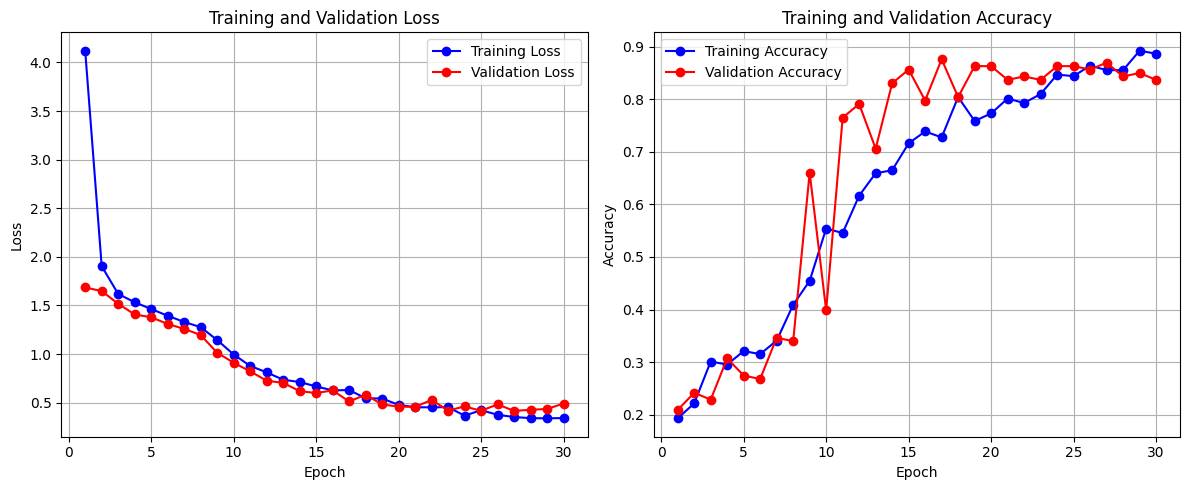

In [ ]:
epochs = range(1, len(train_losses) + 1)  #matches training length

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
plt.plot(epochs, val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


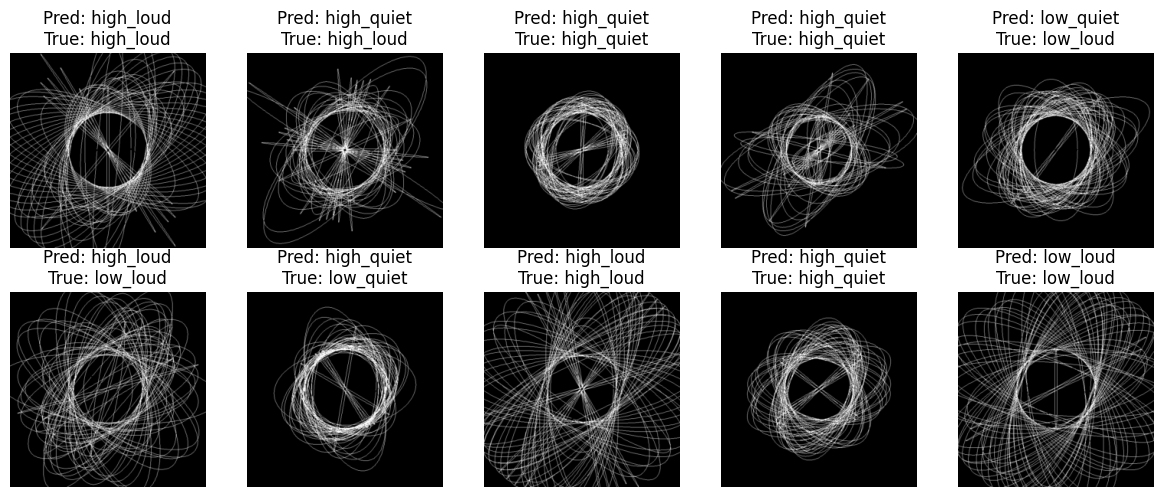

In [ ]:

#TESTING RANDOM PICTURES
# Pick 10 random indices from the whole test dataset
num_samples = 10
random_indices = random.sample(range(len(test_dataset)), num_samples)

model.eval()
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        img, label = test_dataset[idx]                 # Get image and true label
        input_img = img.unsqueeze(0).to(device)       # Add batch dim and move to device
        output = model(input_img)
        _, pred = torch.max(output, 1)                # Get predicted class

        img_display = img.squeeze(0).cpu()            # Remove channel for grayscale display
        axes[i].imshow(img_display, cmap='gray')
        axes[i].set_title(f"Pred: {classes[pred.item()]}\nTrue: {classes[label]}")
        axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
_, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Test accuracy: {test_accuracy:.2%}")

Accuracy on the full test dataset: 83.66%


## 2.5: Save the Trained Model and Training History


### Saving the Model
Saving the model involves storing its learned parameters so you can reuse the trained network later. In PyTorch, this is typically done by saving the model's state dictionary, which contains all the weights and biases. This file is compact and can be loaded into the same model architecture to restore its trained state without retraining. Saving just the state dictionary is preferred over saving the entire model object because it offers more flexibility and compatibility across different environments.

### Saving the Model’s State Dictionary:
This means storing all the learned parameters (weights and biases) of the model after training. This allows you to save the trained model so you can load it later without retraining from scratch. The state dictionary contains only the model parameters, making it lightweight and flexible to use with the same model architecture when you want to perform inference or continue training.

### Saving the Training History
Saving training history means storing information about the model’s performance during training, such as loss and accuracy for each epoch. Keeping this history allows you to analyze how the model learned over time, visualize trends, compare different training runs, and identify issues like overfitting or underfitting. Typically, training history is saved in a simple format like JSON so it can be easily loaded later for plotting or further analysis.

In [ ]:
torch.save(model.state_dict(), 'spiro_miniproject.pth')
from google.colab import files
files.download('spiro_miniproject.pth')

In [ ]:
# import json

# lab_dir = './results'
# os.makedirs(lab_dir, exist_ok=True)  # ensure directory exists

# # Save model
# model_save_path = os.path.join(lab_dir, 'simplecnn_spyrographsTESTDATA.pth')
# torch.save(model.state_dict(), model_save_path)
# print(f"Model saved to {model_save_path}")

# # Save training history
# training_history = {
#     'train_loss': train_losses,
#     'train_acc': train_accuracies,
#     'val_loss': val_losses,
#     'val_acc': val_accuracies
# }

# history_save_path = os.path.join(lab_dir, 'training_history.json')
# with open(history_save_path, 'w') as f:
#     json.dump(training_history, f)
# print(f"Training history saved to {history_save_path}")


Model saved to ./results/simplecnn_spyrographsTESTDATA.pth
Training history saved to ./results/training_history.json


In [ ]:
os.listdir()

['.config', 'dataset2 3.zip', 'data', 'results', 'sample_data']

In [ ]:
model.load_state_dict(
    torch.load('/content/results/spiro_miniproject.pth')
    )

FileNotFoundError: [Errno 2] No such file or directory: '/content/results/simplecnn_spyrographs.pth'

In [ ]:
from google.colab import files
files.download('/content/results/spiro_miniproject.pth')


##To Load a Saved Model:

In [ ]:
model = SimpleCNN(num_classes=4)
model.load_state_dict(torch.load('/content/results/spiro_miniproject.pth'))
model.eval()